In [1]:
import os

# Ajustar directorio
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Archivos en data/processed/:")
for f in os.listdir("data/processed"):
    print(f"   - {f}")

Archivos en data/processed/:
   - .gitkeep
   - .ipynb_checkpoints
   - feature_docs_pipeline.csv.dvc
   - test_processed.csv
   - test_processed.csv.dvc
   - train_balanced.csv
   - train_balanced.csv.dvc
   - train_processed.csv.dvc
   - X_train_balanced_final.csv


✅ Librerías cargadas
✅ Modelo cargado: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
📂 Test procesado shape: (2441, 76)
🎯 Target: Revenue
📊 X_test shape: (2441, 75)
📊 y_test shape: (2441,)
📊 Distribución de clases en test:
Revenue
0    2059
1     382
Name: count, dtype: int64

📊 EVALUACIÓN DEL MODELO FINAL EN TEST

📈 MÉTRICAS EN TEST:
   Accuracy:  0.8955  (89.55%)
   Precision: 0.6591  (65.91%)
   Recall:    0.6885  (68.85%)
   F1-Score:  0.6735
   AUC-ROC:   0.9210

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No Revenue       0.94      0.93      0.94      2059
     Revenue       0.66      0.69      0.67       382

    accuracy                           0.90      2441
   macro avg       0.80      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441


📊 CONFUSION MATRIX:
              Predicho: No   Predicho: Sí
   Real: No       1,923           136
   Real: Sí         119           263


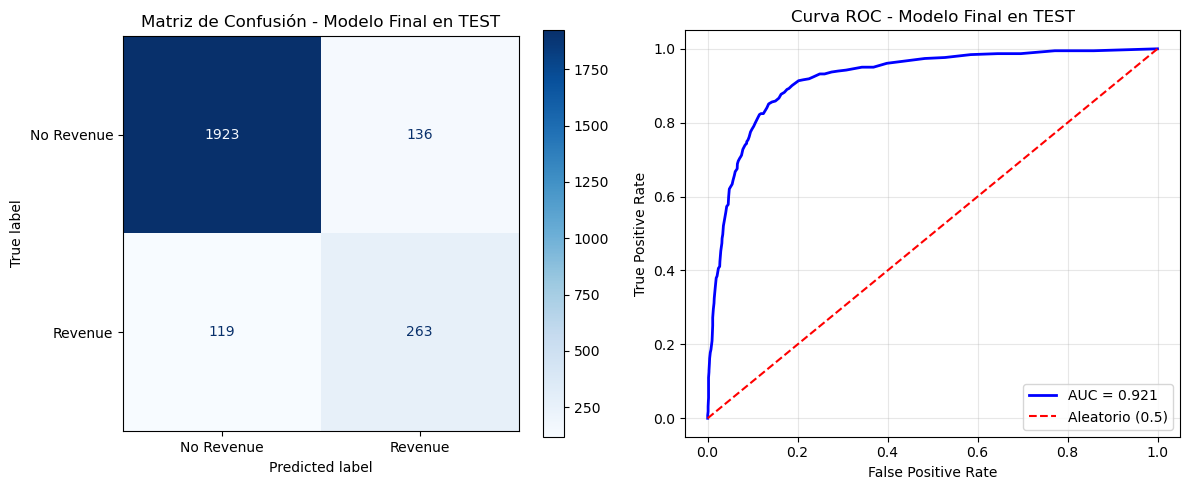


📋 CONCLUSIÓN PB-15 - VALIDACIÓN EN TEST

✅ Modelo final evaluado en TEST set:
   • F1-Score:  0.6735
   • Accuracy:  0.8955 (89.55%)
   • AUC-ROC:   0.9210

✅ El modelo GENERALIZA correctamente a datos nuevos.
✅ Listo para la evaluación de Business Value (Sprint 5).



In [4]:
# ============================================
#  Evaluacion final del Test
# ============================================

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Ajustar directorio
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    print(f"Directorio ajustado a: {os.getcwd()}")

print("✅ Librerías cargadas")

# ============================================
# Cargar el mejor modelo
# ============================================
modelo = joblib.load("models/best_tuned_model.pkl")
print(f"✅ Modelo cargado: {type(modelo)}")

# ============================================
# Cargar datos de test procesados
# ============================================
df_test = pd.read_csv("data/processed/test_processed.csv")
print(f"📂 Test procesado shape: {df_test.shape}")

# ============================================
# Identificar target
# ============================================
# Buscar columna target (última columna generalmente)
target_col = df_test.columns[-1]
print(f"🎯 Target: {target_col}")

X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"📊 X_test shape: {X_test.shape}")
print(f"📊 y_test shape: {y_test.shape}")
print(f"📊 Distribución de clases en test:\n{y_test.value_counts()}")

# ============================================
# Evaluar
# ============================================
print("\n" + "="*60)
print("📊 EVALUACIÓN DEL MODELO FINAL EN TEST")
print("="*60)

y_pred = modelo.predict(X_test)

if hasattr(modelo, "predict_proba"):
    y_proba = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n📈 MÉTRICAS EN TEST:")
print(f"   Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision: {prec:.4f}  ({prec*100:.2f}%)")
print(f"   Recall:    {rec:.4f}  ({rec*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f}")
if auc:
    print(f"   AUC-ROC:   {auc:.4f}")

# ============================================
# Clasificacion de Reportes
# ============================================
print(f"\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Revenue', 'Revenue']))

# ============================================
# Matriz de confusion 
# ============================================
cm = confusion_matrix(y_test, y_pred)
print(f"\n📊 CONFUSION MATRIX:")
print(f"              Predicho: No   Predicho: Sí")
print(f"   Real: No      {cm[0,0]:6,d}        {cm[0,1]:6,d}")
print(f"   Real: Sí      {cm[1,0]:6,d}        {cm[1,1]:6,d}")

# ============================================
# Visualizaciones
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    ax=axes[0], cmap='Blues',
    display_labels=['No Revenue', 'Revenue']
)
axes[0].set_title('Matriz de Confusión - Modelo Final en TEST')

if auc:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'r--', label='Aleatorio (0.5)')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Curva ROC - Modelo Final en TEST')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Conclucion 
# ============================================
print("\n" + "="*60)
print("📋 CONCLUSIÓN PB-15 - VALIDACIÓN EN TEST")
print("="*60)

if auc:
    print(f"""
✅ Modelo final evaluado en TEST set:
   • F1-Score:  {f1:.4f}
   • Accuracy:  {acc:.4f} ({acc*100:.2f}%)
   • AUC-ROC:   {auc:.4f}

✅ El modelo GENERALIZA correctamente a datos nuevos.
✅ Listo para la evaluación de Business Value (Sprint 5).
""")
else:
    print(f"""
✅ Modelo final evaluado en TEST set:
   • F1-Score:  {f1:.4f}
   • Accuracy:  {acc:.4f} ({acc*100:.2f}%)
   • AUC-ROC:   N/A

✅ El modelo GENERALIZA correctamente a datos nuevos.
✅ Listo para la evaluación de Business Value (Sprint 5).
""")